In [3]:
from pathlib import Path
import importlib
import logging
import sys
import os

logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")

# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"

logger.info(f"module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
else:
    logger.info("Module path already inserted into system paths")

try:
    from model import markov_chain
    from model import probabilistic_analysis as psa
    from model import visualization
    from model import constants
    from model import utils

    # to apply changes in modules
    importlib.reload(markov_chain)
    importlib.reload(psa)
    importlib.reload(visualization)
    importlib.reload(constants)
    importlib.reload(utils)
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: module directory: /home/mohammad/projects/Thesis/hemophilia
INFO: Module path already inserted into system paths


In [4]:
# Model inputs
base_sample_size = 128
short_steps = constants.SHORT_TERM_CYCLE_COUNTS
long_steps = constants.LONG_TERM_CYCLE_COUNTS
ssp = constants.START_SIMULATION_AGE_IN_WEEK

# Loading states name from excel sheet is deprecated, now on only generate within the code blocks
start_state = constants.START_STATE
primary_states = constants.PRIMARY_STATES
secondary_states = constants.SECONDARY_STATES
# NOTE:
# Transition matrix is dynamically generated through the *_psa functions as they sample from abr values
# To change in states need to update the psa worker functions as well to support new model schema
# NOTE:
# Newly suggested model structure:               switch
#                   [Healthy]                    ------>                     [Arthropathy]
#        |              |              |                           |              |              |
# [LT Bleeding] | [Hemarthrosis] | [Bleeding]               [LT Bleeding] | [Hemarthrosis] | [Bleeding]
#    |                  |                                          |
# [DEATH]         [Arthropathy]                                 [DEATH]
chains = {"primary": (primary_states, {}), "secondary": (secondary_states, {})}


# Define switch conditions
def arthropathy_switch_condition(step: int, state: str, chain: str, **kwargs) -> bool:
    """Determine if a switch to the secondary chain should occur based on the Arthropathy state."""
    return state == "Arthropathy" and chain == "primary"

switch_conditions = {"secondary": arthropathy_switch_condition}

In [5]:
weights = [utils.cal_body_weight(w, b=ssp) for w in range(short_steps)]
# Short term simulation
on_demand_inputs, on_demand_outputs = psa.markov_chains_psa_wrapper(
    strategy="on_demand",
    n_samples=base_sample_size,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=short_steps,
    switch_conditions=switch_conditions,
)

prophylaxis_inputs, prophylaxis_outputs = psa.markov_chains_psa_wrapper(
    strategy="prophylaxis",
    n_samples=base_sample_size,
    chains=chains,
    start_chain="primary",
    start_state="Healthy",
    steps=short_steps,
    switch_conditions=switch_conditions,
)

Text(0.5, 0, 'age (year)')

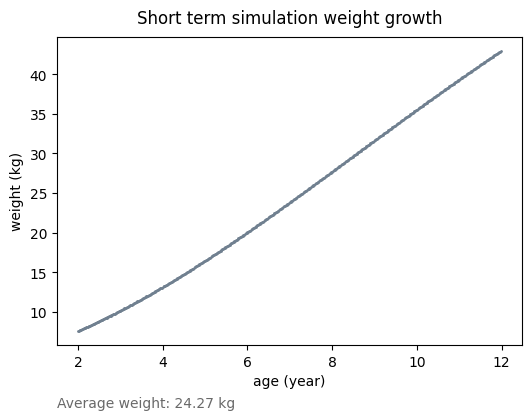

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.scatter(x=[((val + ssp) / 52) for val in range(len(weights))], y=weights, s=1, color="slategray")
ax.set_title("Short term simulation weight growth", pad=10)
ax.text(1.5, -2, f"Average weight: {round(np.mean(weights), 2)} kg", color="dimgray")
ax.set_ylabel("weight (kg)")
ax.set_xlabel("age (year)")

In [7]:
# ---- Debug cell ----
debug = True

# Graphs stores at outputs/figures/transitions
if debug:
    # on_demand simulation transition matrix graph
    for i, inputs in enumerate(np.random.choice(on_demand_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"on-demand-primary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"on-demand-secondary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
    # prophylaxis simulation transition matrix graph
    for i, inputs in enumerate(np.random.choice(prophylaxis_inputs, size=5)):
        chains = inputs["chains"]
        primary_matrix = chains["primary"][1]
        secondary_matrix = chains["secondary"][1]
        visualization.visualize_transition_matrix(
            matrix=primary_matrix,
            states=primary_states,
            title=f"prophylaxis-primary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )
        visualization.visualize_transition_matrix(
            matrix=secondary_matrix,
            states=secondary_states,
            title=f"prophylaxis-secondary-{int(round(inputs['abr'],0))}-{int(round(inputs['ajbr'], 0))}",
        )

In [8]:
import pandas as pd

df = pd.DataFrame(
    columns=[
        "on_demand_mean",
        "on_demand_median",
        "prophylaxis_mean",
        "prophylaxis_median",
    ],
)

on_demand_arthropathy = [
    op for op in on_demand_outputs if op.sequences.count("Arthropathy") > 0
]
prophylaxis_arthropathy = [
    op for op in prophylaxis_outputs if op.sequences.count("Arthropathy") > 0
]
# On_Demand results
od_consumption = [op.annual_factor_consumption for op in on_demand_outputs]
od_costs = [op.annual_factor_costs for op in on_demand_outputs]
od_qalys = [op.qaly for op in on_demand_outputs]

# Means
df.loc["annual iu", "on_demand_mean"] = np.mean(od_consumption)
df.loc["annual iu/kg", "on_demand_mean"] = np.mean(od_consumption) / np.mean(weights)
df.loc["annual costs ($)", "on_demand_mean"] = np.mean(od_costs)
df.loc["qaly", "on_demand_mean"] = np.mean(od_qalys)

# Medians
df.loc["annual iu", "on_demand_median"] = np.median(od_consumption)
df.loc["annual iu/kg", "on_demand_median"] = np.median(od_consumption) / np.median(
    weights
)
df.loc["annual costs ($)", "on_demand_median"] = np.median(od_costs)
df.loc["qaly", "on_demand_median"] = np.median(od_qalys)


# Prophylaxis results
pro_consumption = [op.annual_factor_consumption for op in prophylaxis_outputs]
pro_costs = [op.annual_factor_costs for op in prophylaxis_outputs]
pro_qalys = [op.qaly for op in prophylaxis_outputs]

# Means
df.loc["annual iu", "prophylaxis_mean"] = np.mean(pro_consumption)
df.loc["annual iu/kg", "prophylaxis_mean"] = np.mean(pro_consumption) / np.mean(weights)
df.loc["annual costs ($)", "prophylaxis_mean"] = np.mean(pro_costs)
df.loc["qaly", "prophylaxis_mean"] = np.mean(pro_qalys)

# Medians
df.loc["annual iu", "prophylaxis_median"] = np.median(pro_consumption)
df.loc["annual iu/kg", "prophylaxis_median"] = np.median(pro_consumption) / np.median(
    weights
)
df.loc["annual costs ($)", "prophylaxis_median"] = np.median(pro_costs)
df.loc["qaly", "prophylaxis_median"] = np.median(pro_qalys)

# ICER value
d_costs = round(np.sum(pro_costs) - np.sum(od_costs), 2)
d_qalys = round(np.sum(pro_qalys) - np.sum(od_qalys), 2)
icer = round(d_costs / d_qalys, 2)

sample_size = len(on_demand_inputs)
# On demand arthropathy results
od_arthro_len = len(on_demand_arthropathy)
od_healthy_fraction = round(1 - (od_arthro_len / sample_size), 2)
# Prophylaxis arthropathy results
pro_arthro_len = len(prophylaxis_arthropathy)
pro_healthy_fraction = round(1 - (pro_arthro_len / sample_size), 2)

# Net monetary benefits
net_monetary_benefit = round((constants.WTP_THRESHOLD * (d_qalys/sample_size)) - (d_costs/sample_size), 2)


In [9]:
# Study reviewed from england journal suggests 93% of prophylaxis and 55% of on demand had normal joint MRI
# But the radio graphic results indicate 93% and 81% had no joint damage
print(
    f"""
    [Short Term]
    Simulation results for {int(short_steps/52)} Years (2 - 13)
    {len(on_demand_inputs)} samples
    
    Number of simulations transitioned to chronic arthropathy:
    On demand: {len(on_demand_arthropathy)}, Prophylaxis: {len(prophylaxis_arthropathy)}
    Percentage of normal joints:
    On demand: {od_healthy_fraction}%, Prophylaxis: {pro_healthy_fraction}%
    
    {round(d_qalys / sample_size, 2)} qaly gained with ${round(d_costs / sample_size, 2)} increase in cost of treatment
    Incremental cost effectiveness ratio: ${round(icer, 2):,}
    Willingness to pay threshold: ${round(constants.WTP_THRESHOLD, 2):,}
    NOTE: ICER < WTP indicates intervention was cost effective
    
    Net monetary benefit: ${net_monetary_benefit} (Intervention was cost effective)
    """
)
df.head()


    [Short Term]
    Simulation results for 10 Years (2 - 13)
    2816 samples
    
    Number of simulations transitioned to chronic arthropathy:
    On demand: 1265, Prophylaxis: 243
    Percentage of normal joints:
    On demand: 0.55%, Prophylaxis: 0.91%
    
    3.1 qaly gained with $42651.74 increase in cost of treatment
    Incremental cost effectiveness ratio: $13,750.09
    Willingness to pay threshold: $14,314.2
    NOTE: ICER < WTP indicates intervention was cost effective
    
    Net monetary benefit: $1749.83 (Intervention was cost effective)
    


,on_demand_mean,on_demand_median,prophylaxis_mean,prophylaxis_median
annual iu,13738.037464,8707.95,99901.907244,97684.95
annual iu/kg,566.020114,366.034048,4116.052899,4106.134931
annual costs ($),6800.428206,4310.498421,49452.168816,48354.758897
qaly,4.723782,4.73476,7.825708,8.985962


In [ ]:
# Value to report:
# Report no. of factor viii infusions [ ]
# Report no. of factor viii unit infused [ ]
# Report no. of factor viii unit infused per kg [ ]
# Report annual cost of factor viii / kg [ ]
# Report annual joint hemorrhages [ ]
# Report annual bleeding rate [ ]
# Report quality adjusted life year [ ]
# Report Incremental cost effectiveness ratio [ ]
# Report Net monetary benefit [√]